# 03 — Final Model, Decision Policy & Scored Portfolio

The chosen configuration (from `02_experiments.ipynb`): logistic regression, L2,
C=0.05, unweighted, on the 8 raw financials + one-hot sector/country, preprocessing
inside the pipeline. This notebook is the model's full report card and produces the
deliverable review:

1. Cross-validated performance and out-of-fold diagnostics (ROC, PR, reliability)
2. What drives the score (global coefficients — and how per-company memos reuse them)
3. The decision policy: validated risk ratings + cost-based alert threshold
4. The 50 scored companies, the drift check, and sample analyst memos

Everything is computed through `src/` — the notebook *demonstrates* the engine, it does
not reimplement it. The deliverable itself is produced by `uv run python run.py`.

### 4b. Sample analyst memos

Three companies from the scoring book — highest, median, and lowest predicted risk.
The deliverable CSV (`outputs/predictions.csv`) is written by `uv run python run.py`.


In [8]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.config import CATEGORICAL, ID, NUMERIC, TARGET
from src.data import check_consistency, load_scoring, load_training
from src.explain import build_all_explanations
from src.model import cv_metrics, make_model, oof_predictions, oof_report
from src.policy import expected_cost, rating_validation, select_threshold, to_rating

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110

train = load_training()
scoring = load_scoring()
X, y = train[NUMERIC + CATEGORICAL], train[TARGET]

pipe = make_model()
m = cv_metrics(pipe, X, y)
print(f"RepeatedStratifiedKFold(5x3), {m['n_fits']} fits:")
print(f"  ROC-AUC {m['roc_auc']:.3f} ± {m['roc_auc_std']:.3f}")
print(f"  PR-AUC  {m['pr_auc']:.3f} ± {m['pr_auc_std']:.3f}  (base rate {y.mean():.2f})")
print(f"  Brier   {m['brier']:.3f}")

RepeatedStratifiedKFold(5x3), 15 fits:
  ROC-AUC 0.806 ± 0.034
  PR-AUC  0.531 ± 0.058  (base rate 0.17)
  Brier   0.114


## 1. Out-of-fold diagnostics

Every training row gets one prediction from a model that never saw it. Three curves:
**ROC** (ranking), **precision–recall** (what the top of the risk ranking looks like
against the 17% base rate), and **reliability** (do predicted probabilities match
observed default frequencies? — they should, since we deliberately avoided class
weighting).

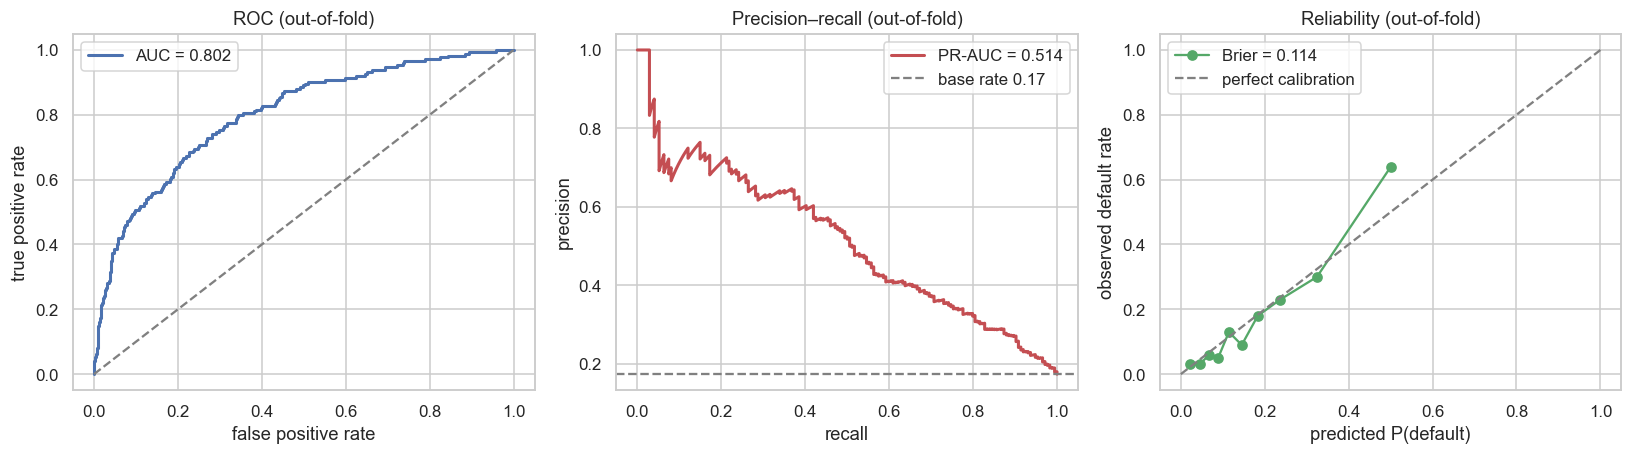

In [9]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve, roc_curve

probs_oof, fold_ids = oof_predictions(pipe, X, y)
rep = oof_report(y, probs_oof)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

fpr, tpr, _ = roc_curve(y, probs_oof)
axes[0].plot(fpr, tpr, lw=2, color="#4c72b0", label=f"AUC = {rep['roc_auc']:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set(title="ROC (out-of-fold)", xlabel="false positive rate", ylabel="true positive rate")
axes[0].legend()

prec, rec, _ = precision_recall_curve(y, probs_oof)
axes[1].plot(rec, prec, lw=2, color="#c44e52", label=f"PR-AUC = {rep['pr_auc']:.3f}")
axes[1].axhline(y.mean(), ls="--", color="gray", label=f"base rate {y.mean():.2f}")
axes[1].set(title="Precision–recall (out-of-fold)", xlabel="recall", ylabel="precision")
axes[1].legend()

frac_pos, mean_pred = calibration_curve(y, probs_oof, n_bins=10, strategy="quantile")
axes[2].plot(mean_pred, frac_pos, "o-", color="#55a868", label=f"Brier = {rep['brier']:.3f}")
axes[2].plot([0, 1], [0, 1], "--", color="gray", label="perfect calibration")
axes[2].set(title="Reliability (out-of-fold)", xlabel="predicted P(default)",
            ylabel="observed default rate")
axes[2].legend()

plt.tight_layout()
plt.show()

## 2. What drives the score

Standardized coefficients are the model's global story — and, because the model is
linear, each company's memo decomposes its own score into exactly these terms
(`coef × standardized value`, the linear special case of SHAP — see `src/explain.py`).

### 2a. Coefficients


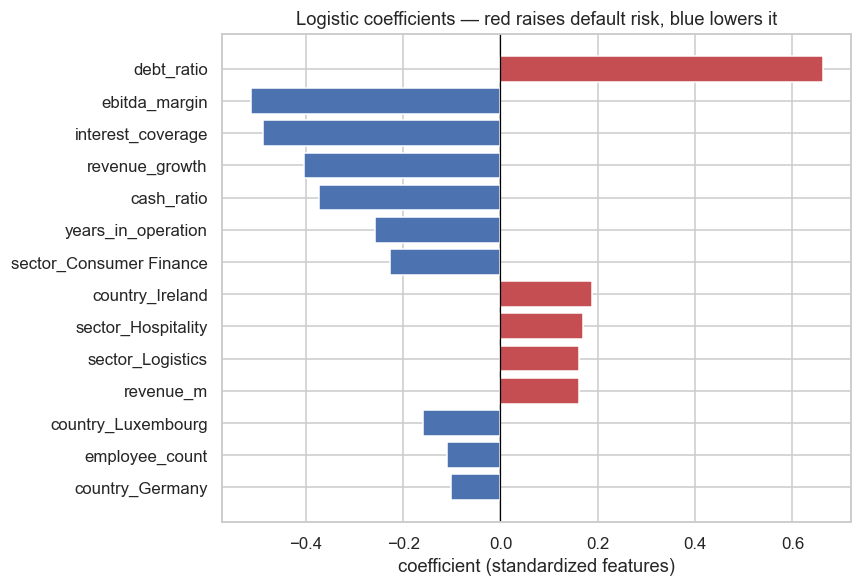

Financial drivers (standardized):
debt_ratio            0.662
ebitda_margin        -0.513
interest_coverage    -0.488
revenue_growth       -0.404
cash_ratio           -0.373
years_in_operation   -0.258
revenue_m             0.161
employee_count       -0.109


In [10]:
pipe.fit(X, y)
ohe = pipe.named_steps["prep"].named_transformers_["cat"].named_steps["ohe"]
feat_names = NUMERIC + list(ohe.get_feature_names_out(CATEGORICAL))
coefs = pd.Series(pipe.named_steps["clf"].coef_[0], index=feat_names)

top = coefs.reindex(coefs.abs().sort_values(ascending=False).index)[:14]
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top.index[::-1], top.values[::-1],
        color=["#c44e52" if v > 0 else "#4c72b0" for v in top.values[::-1]])
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Logistic coefficients — red raises default risk, blue lowers it")
ax.set_xlabel("coefficient (standardized features)")
plt.tight_layout()
plt.show()

print("Financial drivers (standardized):")
print(coefs[NUMERIC].sort_values(key=abs, ascending=False).round(3).to_string())

### 2b. Permutation importance (cross-check)

Model-agnostic sanity check: shuffle each input column and measure how much AUC
drops on a held-out view. Agreement with the coefficient ranking means the linear
reading is not an artefact of the model form.


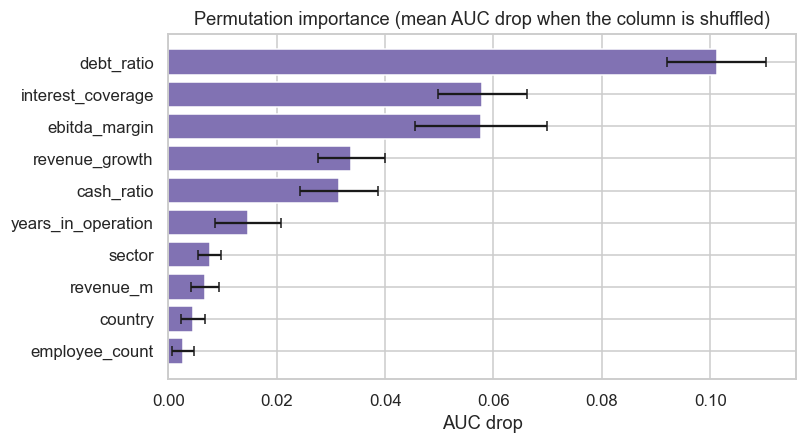

In [11]:
from sklearn.inspection import permutation_importance

# Model-agnostic cross-check of the coefficient story: how much does OOF-style AUC
# drop when each input column is shuffled? Agreement between the two views means the
# linear reading of the drivers is not an artefact of the model form.
perm = permutation_importance(pipe, X, train[TARGET], scoring="roc_auc",
                              n_repeats=20, random_state=42, n_jobs=-1)
imp = (pd.Series(perm.importances_mean, index=NUMERIC + CATEGORICAL)
       .sort_values())

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.barh(imp.index, imp.values,
        xerr=perm.importances_std[np.argsort(perm.importances_mean)],
        color="#8172b3", capsize=3)
ax.set_title("Permutation importance (mean AUC drop when the column is shuffled)")
ax.set_xlabel("AUC drop")
plt.tight_layout()
plt.show()

Sign-correct throughout: leverage raises risk; coverage, margins, growth, liquidity and
tenure protect. A credit committee can audit every term — and the model-agnostic
permutation view ranks the same drivers in the same order as the coefficients.

## 3. Decision policy

Two instruments from `src/policy.py`, both validated on out-of-fold predictions:

- **Risk ratings** (the memo's headline): probability cutoffs at 0.10 / 0.25, legitimate
  only if observed default risk rises monotonically across the bands;
- **Alert threshold** (the operating point for "send to manual review"): minimises
  expected cost under FN:FP = 5:1, *selected out-of-fold* — for each fold the sweep runs
  on the other four and is evaluated on the held-out fold, so the threshold is never
  graded on the rows that chose it.


,companies,observed_default_rate
risk_rating,,
Low,392,4.3%
Medium,383,15.4%
High,225,43.6%


alert threshold: 0.175 ± 0.019 across folds
at that threshold: recall 0.75, precision 0.35, 37% of the book flagged


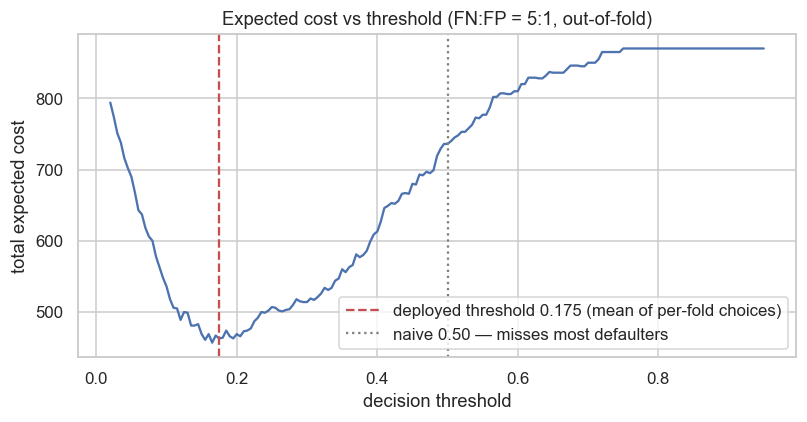

,fold,threshold,heldout_cost
0,0,0.165,88.0
1,1,0.195,98.0
2,2,0.195,131.0
3,3,0.165,97.0
4,4,0.155,76.0


In [12]:
bands = rating_validation(y.to_numpy(), probs_oof)
display(bands.style.format({"observed_default_rate": "{:.1%}"}))
assert bands["observed_default_rate"].is_monotonic_increasing, "bands must be monotone"

th = select_threshold(y.to_numpy(), probs_oof, fold_ids)
print(f"alert threshold: {th['threshold']:.3f} ± {th['threshold_std']:.3f} across folds")
print(f"at that threshold: recall {th['recall']:.2f}, precision {th['precision']:.2f}, "
      f"{th['flagged_share']:.0%} of the book flagged")

grid = np.linspace(0.02, 0.95, 187)
costs = [expected_cost(y.to_numpy(), probs_oof, t) for t in grid]
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(grid, costs, color="#4c72b0")
ax.axvline(th["threshold"], ls="--", color="#c44e52",
           label=f"deployed threshold {th['threshold']:.3f} (mean of per-fold choices)")
ax.axvline(0.5, ls=":", color="gray", label="naive 0.50 — misses most defaulters")
ax.set(title="Expected cost vs threshold (FN:FP = 5:1, out-of-fold)",
       xlabel="decision threshold", ylabel="total expected cost")
ax.legend()
plt.tight_layout()
plt.show()

display(th["per_fold"].round(3))

## 4. Scoring the 50 unseen companies

Refit on all 1,000 training rows, score, rate, and explain. The drift check first: the
scores are only as trustworthy as the assumption that the scoring population resembles
the training population.

,feature,ks_stat,p_value
0,ebitda_margin,0.272,0.001
1,cash_ratio,0.228,0.012
2,interest_coverage,0.226,0.013
3,debt_ratio,0.204,0.033
4,years_in_operation,0.179,0.084
5,employee_count,0.152,0.202
6,revenue_m,0.125,0.416
7,revenue_growth,0.094,0.763


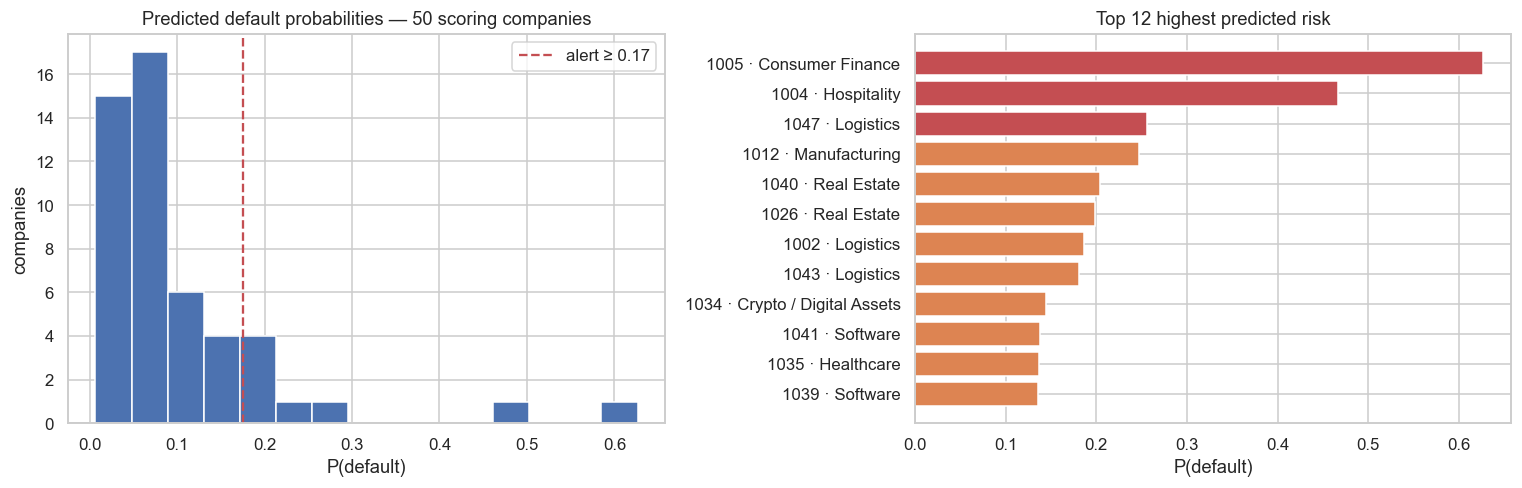

rating distribution: {'Low': 33, 'Medium': 14, 'High': 3}


In [13]:
import warnings

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    drift = check_consistency(train, scoring)
for w in caught:
    print(f"WARNING: {w.message}")
display(drift.round(3))

p_scoring = pipe.predict_proba(scoring[NUMERIC + CATEGORICAL])[:, 1]
ratings = [to_rating(p) for p in p_scoring]
portfolio = scoring[[ID, "sector", "country"]].copy()
portfolio["p_default"] = p_scoring
portfolio["risk_rating"] = ratings

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
axes[0].hist(p_scoring, bins=15, color="#4c72b0", edgecolor="white")
axes[0].axvline(th["threshold"], ls="--", color="#c44e52",
                label=f"alert ≥ {th['threshold']:.2f}")
axes[0].set(title="Predicted default probabilities — 50 scoring companies",
            xlabel="P(default)", ylabel="companies")
axes[0].legend()

top12 = portfolio.nlargest(12, "p_default").iloc[::-1]
band_color = {"Low": "#55a868", "Medium": "#dd8452", "High": "#c44e52"}
axes[1].barh([f"{r[ID]} · {r['sector']}" for _, r in top12.iterrows()],
             top12["p_default"], color=[band_color[b] for b in top12["risk_rating"]])
axes[1].set(title="Top 12 highest predicted risk", xlabel="P(default)")
plt.tight_layout()
plt.show()

print("rating distribution:", portfolio["risk_rating"].value_counts().to_dict())

In [14]:
memos = build_all_explanations(pipe, scoring, train, p_scoring, ratings)

order = np.argsort(p_scoring)
samples = [order[-1], order[len(order) // 2], order[0]]  # highest, median, lowest risk
for i in samples:
    print(f"[{scoring.iloc[i][ID]}]  p = {p_scoring[i]:.1%}  ({ratings[i]})")
    print(f"  {memos[i]}\n")

[1005]  p = 62.7%  (High)
  High risk: estimated default probability 63%. Key concerns: elevated leverage (debt ratio 0.72 vs median 0.42); declining revenue (-10.9% YoY); tight liquidity (cash ratio 0.07 vs median 0.09). Narrative flags weak liquidity position, dependence on a few key accounts. Narrative cites long-term government contracts.

[1048]  p = 6.1%  (Low)
  Low risk: estimated default probability 6%. Key concerns: declining revenue (-12.4% YoY); small workforce (49 employees). Main mitigant: comfortable interest coverage (4.3x). Narrative flags tight cash position. Narrative cites diversified customer base.

[1006]  p = 0.7%  (Low)
  Low risk: estimated default probability 1%. No material financial weaknesses against the portfolio. Main mitigant: modest leverage (debt ratio 0.19). Narrative flags high customer concentration, exposed to volatile commodity prices.



## 5. Summary & limitations

**Performance**
- ROC-AUC **0.806 ± 0.034** (15 CV fits)
- PR-AUC **~0.53** vs **0.17** base rate
- Brier **~0.11** — honest, unweighted probabilities

**Decision layer**
- Ratings monotone: **≈4% / 15% / 44%** observed default (Low / Medium / High)
- Alert threshold **0.175 ± 0.019** (chosen out-of-fold)
- Catches **~75%** of defaulters; flags **~37%** of book (5:1 cost ratio)

**Explanations**
- Deterministic memos: financial drivers vs portfolio medians + narrative signals
- `run.py --llm` optionally rewrites prose; facts validated with safe fallback

**Limitations**
- Synthetic data, no time dimension — no out-of-time validation; monitor drift in production (`ebitda_margin` KS warning is the kind of signal to watch)
- **~0.81 AUC ceiling** is deliberate label noise — chasing it overfits the generator, not credit risk
- **5:1 cost ratio** is an assumption — re-run `src/policy.py` with your own loss-given-default
- Ratings communicate risk; they do not replace the probability — memos carry both